# Imports

In [1]:
import torch
from torch import nn
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from LabelMapper import LabelMapper
from RuralDataset import RuralDataset
from SegmentationModel import SegmentationModel
from Trainer import Trainer
from Evaluator import Evaluator
from ImageProcessor import ImageProcessor

torch.cuda.empty_cache()

# Configuration parameters

In [2]:
DATA_ROOT = 'train'
BATCH_SIZE = 4
LEARNING_RATE = 0.001
NUM_EPOCHS = 20
NUM_CLASSES = 9
MODEL_SAVE_PATH = 'saved_model.pth'

# Device configuration

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')  # Configura per utilizzare la GPU
    print(f"Utilizzo GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')  # Fallback alla CPU
    print("CUDA non disponibile, utilizzo CPU")

Utilizzo GPU: NVIDIA GeForce RTX 5070 Ti


# Transforms initialization

In [4]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Dataset loading and splitting into training and validation sets

In [6]:
# Crea dataset separati con le rispettive trasformazioni
from torch.utils.data import random_split

# Applica la trasformazione di training e validazione ai rispettivi dataset
full_dataset = RuralDataset(root_dir=DATA_ROOT)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Suddividi il dataset in train e val
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Applica le trasformazioni ai sotto-dataset
# NOTA: random_split restituisce Subset, quindi bisogna settare la transform manualmente
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, num_workers=4, shuffle=True,
    pin_memory=True)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, num_workers=4, shuffle=False,
    pin_memory=True)

print(f"Training on {len(train_dataset)} samples, validating on {len(val_dataset)} samples.")

Training on 744 samples, validating on 187 samples.


# Dataset check


--- Visualizzazione di alcune predizioni e label reali ---


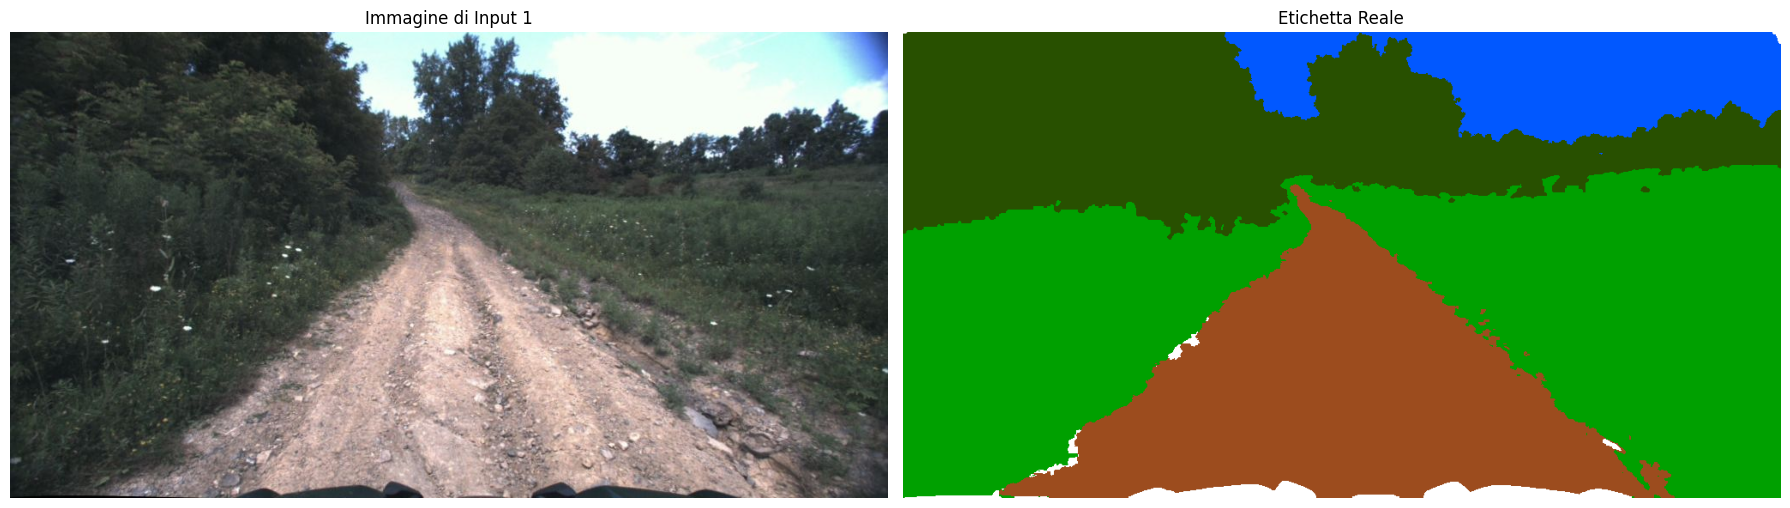

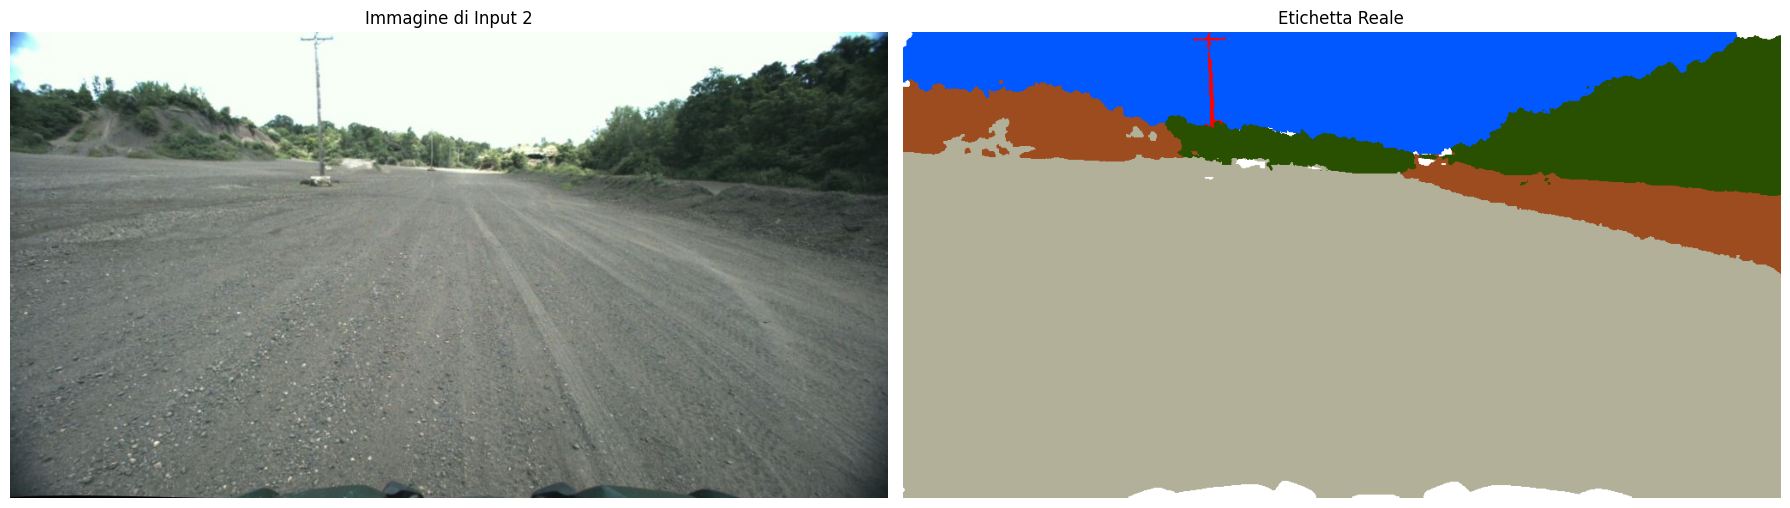

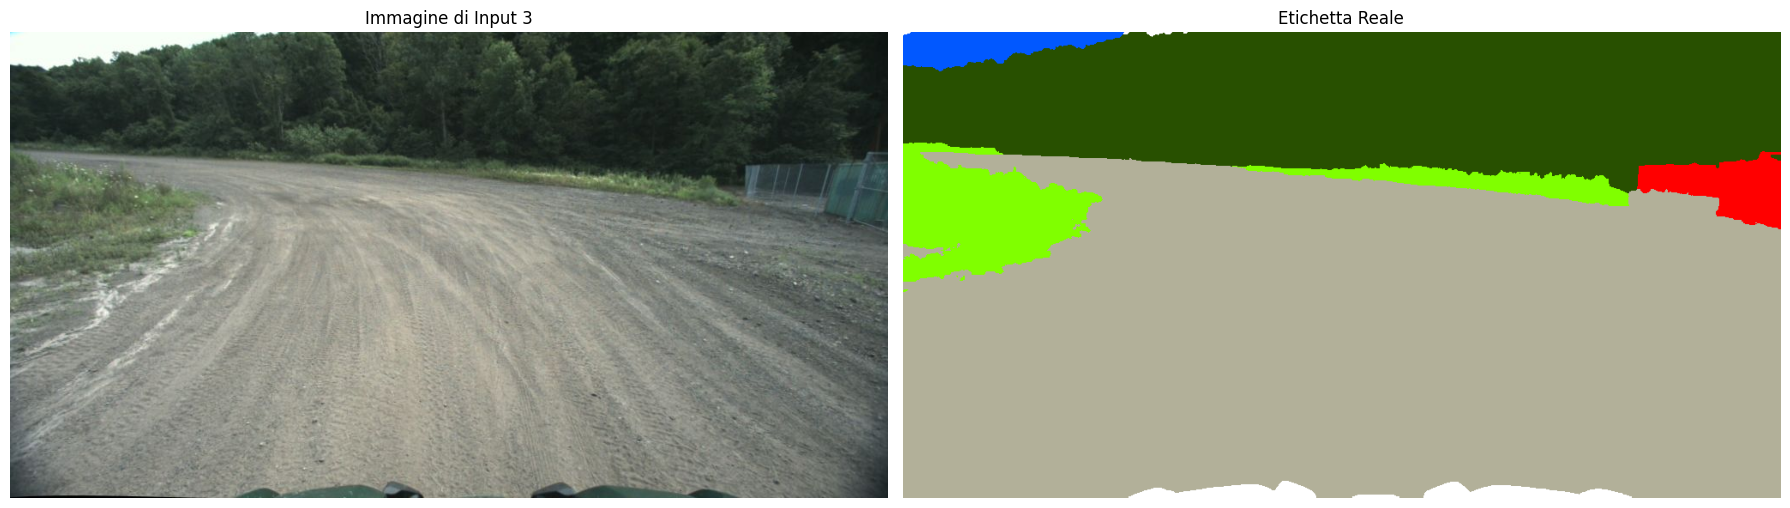

Visualizzazione degli esempi completata.


In [7]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from PIL import Image


COLOR_TO_ID = {
    (255, 255, 255): 0,   # Background
    (1, 88, 255): 1,      # Sky (corretto da 8 a 88)
    (156, 76, 30): 2,     # Rough Trail
    (178, 176, 153): 3,   # Smooth Trail
    (128, 255, 0): 4,     # Traversable grass
    (40, 80, 0): 5,       # High Vegetation
    (0, 160, 0): 6,       # Non Traversable Low Vegetation
    (255, 0, 128): 7,     # Puddle
    (255, 0, 0): 8        # Obstacle
}

ID_TO_COLOR = {v: k for k, v in COLOR_TO_ID.items()}
# Assicurati che ID_TO_COLOR, predict_transform_pipeline,
# best_model, device, val_loader siano definiti e accessibili.

# --- Funzione per convertire gli ID di classe in colori RGB ---
def id_to_rgb_mask(id_mask_np, id_to_color_map):
    """
    Converte una maschera di ID numerici in un'immagine RGB colorata.
    Args:
        id_mask_np (np.ndarray): Maschera con ID di classe (H, W).
        id_to_color_map (dict): Mapping da ID a tupla colore (R, G, B).
    Returns:
        np.ndarray: Immagine RGB colorata (H, W, 3).
    """
    h, w = id_mask_np.shape
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for class_id, color_rgb in id_to_color_map.items():
        rgb_mask[id_mask_np == class_id] = color_rgb
    return rgb_mask

# --- Visualizzazione di Esempi Reali ---
print("\n--- Visualizzazione di alcune predizioni e label reali ---")

# Prendi un batch di immagini dal dataloader di validazione
# Iteriamo un paio di volte per prendere un batch, o direttamente il primo
num_samples_to_show = 3 # Quanti esempi vuoi visualizzare
samples_shown = 0

# Converti mean e std in tensori per operazioni con img_tensor
mean_tensor = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
std_tensor = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)


for i, (images_tensor, labels_tensor) in enumerate(val_loader):
    if samples_shown >= num_samples_to_show:
        break

    # Sposta i dati sul device per la previsione
    images_tensor = images_tensor.to(device)
    labels_tensor = labels_tensor.to(device)

    # Itera su ogni immagine nel batch per visualizzare
    for j in range(images_tensor.shape[0]):
        if samples_shown >= num_samples_to_show:
            break

        # Immagine di Input (denormalizzata e convertita a HWC per imshow)
        input_image_tensor = images_tensor[j] # (C, H, W)

        # Denormalizza l'immagine prima della visualizzazione
        # img_display = (input_image_tensor * std_tensor + mean_tensor).permute(1, 2, 0).cpu().numpy()
        # Per semplicità e robustezza, convertiamo in numpy, poi denormalizziamo manualmente
        img_display = input_image_tensor.cpu().numpy() # (C, H, W)
        img_display = img_display.transpose(1, 2, 0) # (H, W, C)
        img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_display = np.clip(img_display, 0, 1) # Assicurati che i valori siano tra 0 e 1 per imshow


        # Maschera di Verità (convertita da tensore a NumPy e poi a RGB)
        true_label_np = labels_tensor[j].cpu().numpy() # (H, W)
        true_label_rgb = id_to_rgb_mask(true_label_np, ID_TO_COLOR)

        # Plot
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))

        axes[0].imshow(img_display)
        axes[0].set_title(f'Immagine di Input {i*BATCH_SIZE + j + 1}')
        axes[0].axis('off')

        axes[1].imshow(true_label_rgb)
        axes[1].set_title(f'Etichetta Reale')
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

        samples_shown += 1

print("Visualizzazione degli esempi completata.")

# Model initialization

In [8]:
model = SegmentationModel()
model.to(device)
print("Model architecture:")
print(model)

Model architecture:
SegmentationModel(
  (double_conv_downs): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
 

# Loss Function and optimizer definition

In [9]:
criterion = CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Trainer initialization and training

In [ ]:
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer, device)
print("\nStarting training...")
trainer.run(num_epochs=NUM_EPOCHS, model_save_path=MODEL_SAVE_PATH)
print("Training finished.")

# Model evaluation

In [11]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH))

evaluator = Evaluator(model, val_loader, device)
metrics = evaluator.evaluate_classification_metrics()

# Example Predict

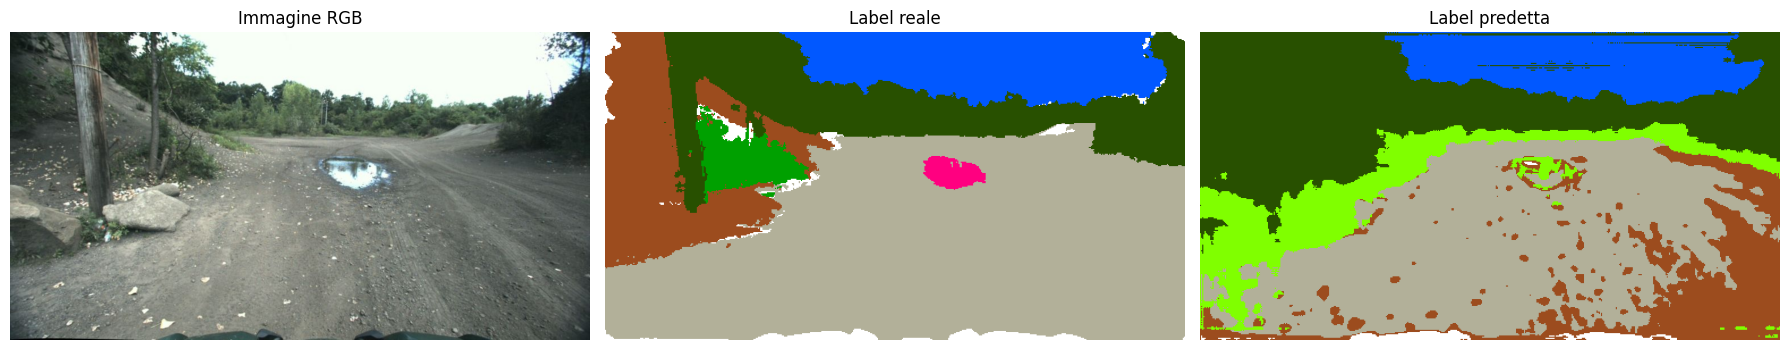

Pixel classificati correttamente: 88664 / 139264 (63.67%)


In [20]:
evaluator.predict_from_folder(folder_number = 510)

In [13]:
print(metrics.get('accuracy', 'N/A'))
print(metrics.get('f1_score', 'N/A'))
print(metrics.get('precision', 'N/A'))
print(metrics.get('recall', 'N/A'))

0.6909546589618886
N/A
0.5006077433711731
0.46268347764733636
